For each class, there is one pattern occurring in the data. Solving just a classification task be scored no higher than 70%.

Please provide either pdf with the report or add some notes in the notebook. Demonstrate some examples of how your approach works.

A short reminder of your task:
 - Correct classification of provided time series
 - Explanation of the prediction (showing which part of which series is responsible for a defect)
 - Neural network with at least one recurrent layer must be used in each step
 - Not the whole logic must be inside the neural network
 - Your approach should work for other data, of course after retraining. It means you shouldn't take advantage of knowing the series are based on sin function and how the anomalies are created.

As a well-known data scientist, you were asked for help by a company producing candies. Some of their products are plagued with different types of defects. The whole manufacture is equipped with sensors so there are several time series describing the process of producing candies. They would like to achieve two goals:


1. Have a predictive model which will tell them if a given candy has a defect and which ones

2. Perform a root cause analysis - they would like to know what patterns in the data are related to defects


Remarks:
• If you achieve only the first goal you will not receive a grade higher than 4.0.

• One candy can have zero, one or more defects at once.

• Patterns are of different length

• Extra task (might help in case of some mistakes) there is one defect related to a pattern occurring at two sensors simultaneously

• For both tasks a recurrent neural network must be used, but there can be some preprocessing and postprocessing steps.

• Your approach should work for other data, of course after retraining. It means you shouldn't take advantage of knowing the series are based on sin function and how the anomalies are created.

• Project should be done in pairs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score

In [2]:
np.random.seed(42)

In [3]:
n = 20000

In [4]:
def createRow(n, classes):
    base = np.sin(np.linspace((np.random.rand(3)),(np.random.rand(3) + np.array([10,15,7])),n))
    if classes[0] > 0:
        base[np.random.randint(0,n), 0] += 2
    if classes[1] > 0:
        base[np.random.randint(0,n), 1] -= 2
    if classes[2] > 0:
        x = np.random.randint(0,n-5)
        base[x:x+4,2] = 0
    if classes[3] > 0:
        x = np.random.randint(0,n-10)
        base[x:x+8,1] += 1.5
    if classes[4] > 0:
        x = np.random.randint(0,n-7)
        base[x:x+6,0] += 1.5
        base[x:x+6,2] -= 1.5
    base += np.random.rand(*base.shape)*.2
    return base

In [5]:
xl, yl = [], []
for _ in range(n):
    cl = np.random.rand(5)<.25
    xl.append(createRow(np.random.randint(40,60), cl))
    yl.append(cl)


[False False False False  True]


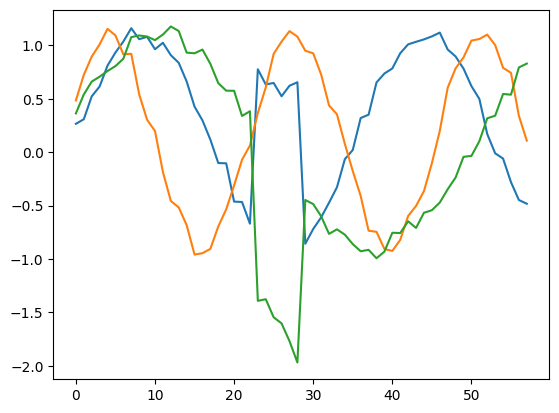

[False False False  True  True]


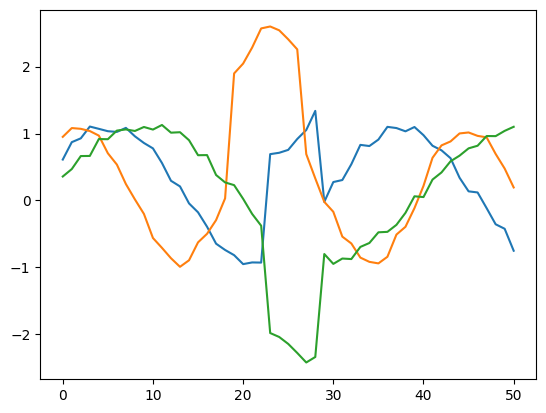

[False False False False False]


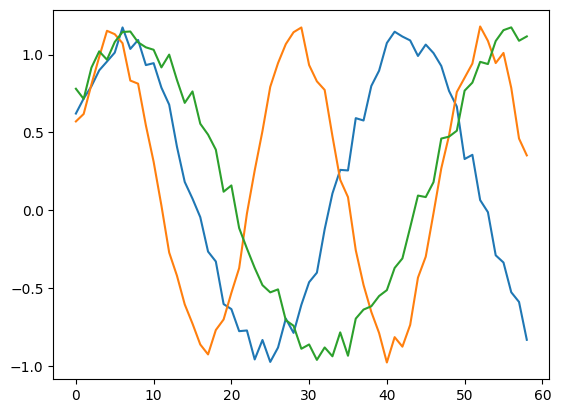

[ True False False False  True]


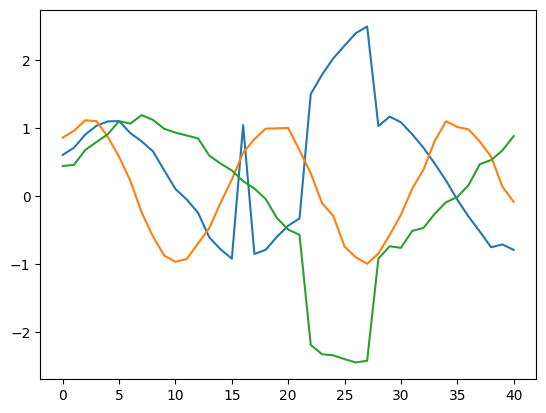

[False  True False False False]


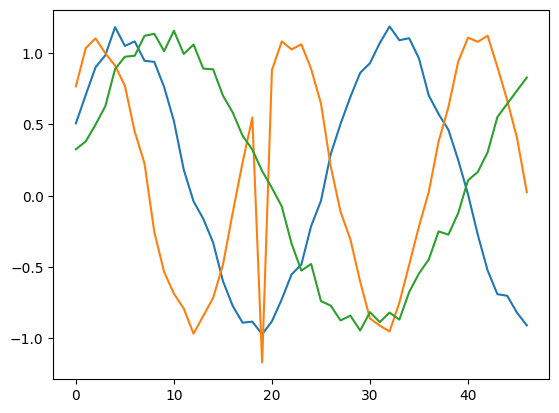

In [6]:
for i in range(5):
    plt.plot(xl[i])
    print(yl[i])
    plt.show()

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score

import matplotlib.pyplot as plt


In [8]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def collate_fn(batch):
    sequences, labels = zip(*batch)

    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)

    sequences = [
        torch.from_numpy(seq).float() for seq in sequences
    ]

    padded = nn.utils.rnn.pad_sequence(
        sequences,
        batch_first=True
    )

    labels = torch.from_numpy(np.array(labels)).float()

    return padded, lengths, labels



In [9]:
class TemporalDefectRNN(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, n_classes=5):
        super().__init__()
        self.rnn = nn.GRU(
            input_dim, hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.temporal_head = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.rnn(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True
        )
        temporal_logits = self.temporal_head(out)
        temporal_probs = torch.sigmoid(temporal_logits)
        return temporal_probs  # (B, T, C)


In [ ]:
def aggregate_predictions(temporal_probs, lengths, mode="max"):
    batch_preds = []
    for i, L in enumerate(lengths):
        valid = temporal_probs[i, :L]
        if mode == "max":
            batch_preds.append(valid.max(dim=0).values)
        else:  
            k = min(5, L)
            batch_preds.append(valid.topk(k, dim=0).values.mean(dim=0))
    return torch.stack(batch_preds)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    xl, yl, test_size=0.2, random_state=42
)

train_ds = TimeSeriesDataset(X_train, y_train)
test_ds  = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)


In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TemporalDefectRNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

"""for epoch in range(20):
    model.train()
    total_loss = 0

    for x, lengths, y in train_loader:
        x, lengths, y = x.to(device), lengths.to(device), y.to(device)

        temporal_probs = model(x, lengths)
        seq_probs = aggregate_predictions(temporal_probs, lengths)

        loss = criterion(seq_probs, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, loss={total_loss/len(train_loader):.4f}")"""


'for epoch in range(20):\n    model.train()\n    total_loss = 0\n\n    for x, lengths, y in train_loader:\n        x, lengths, y = x.to(device), lengths.to(device), y.to(device)\n\n        temporal_probs = model(x, lengths)\n        seq_probs = aggregate_predictions(temporal_probs, lengths)\n\n        loss = criterion(seq_probs, y)\n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n\n        total_loss += loss.item()\n\n    print(f"Epoch {epoch+1}, loss={total_loss/len(train_loader):.4f}")'

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TemporalDefectRNN(
    input_dim=3,
    hidden_dim=64,
    n_classes=5
).to(device)

state_dict = torch.load("model_ph.pth", map_location=device)
model.load_state_dict(state_dict)

model.eval()

TemporalDefectRNN(
  (rnn): GRU(3, 64, batch_first=True, bidirectional=True)
  (temporal_head): Linear(in_features=128, out_features=5, bias=True)
)

In [14]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, lengths, y in test_loader:
        x, lengths = x.to(device), lengths.to(device)
        temporal_probs = model(x, lengths)
        seq_probs = aggregate_predictions(temporal_probs, lengths)

        y_true.append(y.numpy())
        y_pred.append((seq_probs.cpu().numpy() > 0.5).astype(int))

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

print("F1 (macro):", f1_score(y_true, y_pred, average="macro"))
print("Accuracy:", accuracy_score(y_true, y_pred))


F1 (macro): 0.9994175873813955
Accuracy: 0.9985


In [15]:
#torch.save(model.state_dict(), "model_ph.pth")

In [16]:
import matplotlib.patches as patches
def visualize_batch_with_defects(model, X, y, indices, threshold=0.5, max_plots=10):
    model.eval()
    n = min(len(indices), max_plots)
    fig, axs = plt.subplots(n, 1, figsize=(14, 4*n), sharex=False)

    if n == 1:
        axs = [axs] 
    
    colors = ["red", "purple", "cyan", "magenta", "yellow"]
    defect_names = [f"Defect {i}" for i in range(5)]
    defect_patches = [patches.Patch(color=colors[i], label=defect_names[i]) for i in range(len(defect_names))]
    
    for ax_idx, idx in enumerate(indices[:n]):
        seq = torch.tensor(X[idx], dtype=torch.float32).unsqueeze(0).to(next(model.parameters()).device)
        length = torch.tensor([len(X[idx])]).to(next(model.parameters()).device)
        
        with torch.no_grad():
            temporal_probs = model(seq, length)[0].cpu().numpy()
        
        t = np.arange(len(X[idx]))
        
        ax = axs[ax_idx]
        ax.plot(t, X[idx][:,0], label="Sensor 0", color="blue")
        ax.plot(t, X[idx][:,1], label="Sensor 1", color="green")
        ax.plot(t, X[idx][:,2], label="Sensor 2", color="orange")
        
        for k in range(temporal_probs.shape[1]):
            probs = temporal_probs[:, k]
            above_thr = probs > threshold
            
            start = None
            for i, val in enumerate(above_thr):
                if val and start is None:
                    start = i
                elif not val and start is not None:
                    end = i-1
                    ax.add_patch(
                        patches.Rectangle(
                            (start, ax.get_ylim()[0]),
                            end-start+1,
                            ax.get_ylim()[1]-ax.get_ylim()[0],
                            alpha=0.3,
                            color=colors[k % len(colors)]
                        )
                    )
                    start = None
            if start is not None:
                end = len(above_thr)-1
                ax.add_patch(
                    patches.Rectangle(
                        (start, ax.get_ylim()[0]),
                        end-start+1,
                        ax.get_ylim()[1]-ax.get_ylim()[0],
                        alpha=0.3,
                        color=colors[k % len(colors)]
                    )
                )
        
        ax.set_title(f"Sequence {idx} - True labels: {y[idx]}")
        ax.set_xlabel("Time step")
        ax.set_ylabel("Sensor value")
        
        if ax_idx == 0:
            sensor_lines = [ax.lines[0], ax.lines[1], ax.lines[2]]
            ax.legend(handles=sensor_lines + defect_patches, loc="upper right")

    plt.tight_layout()
    plt.show()


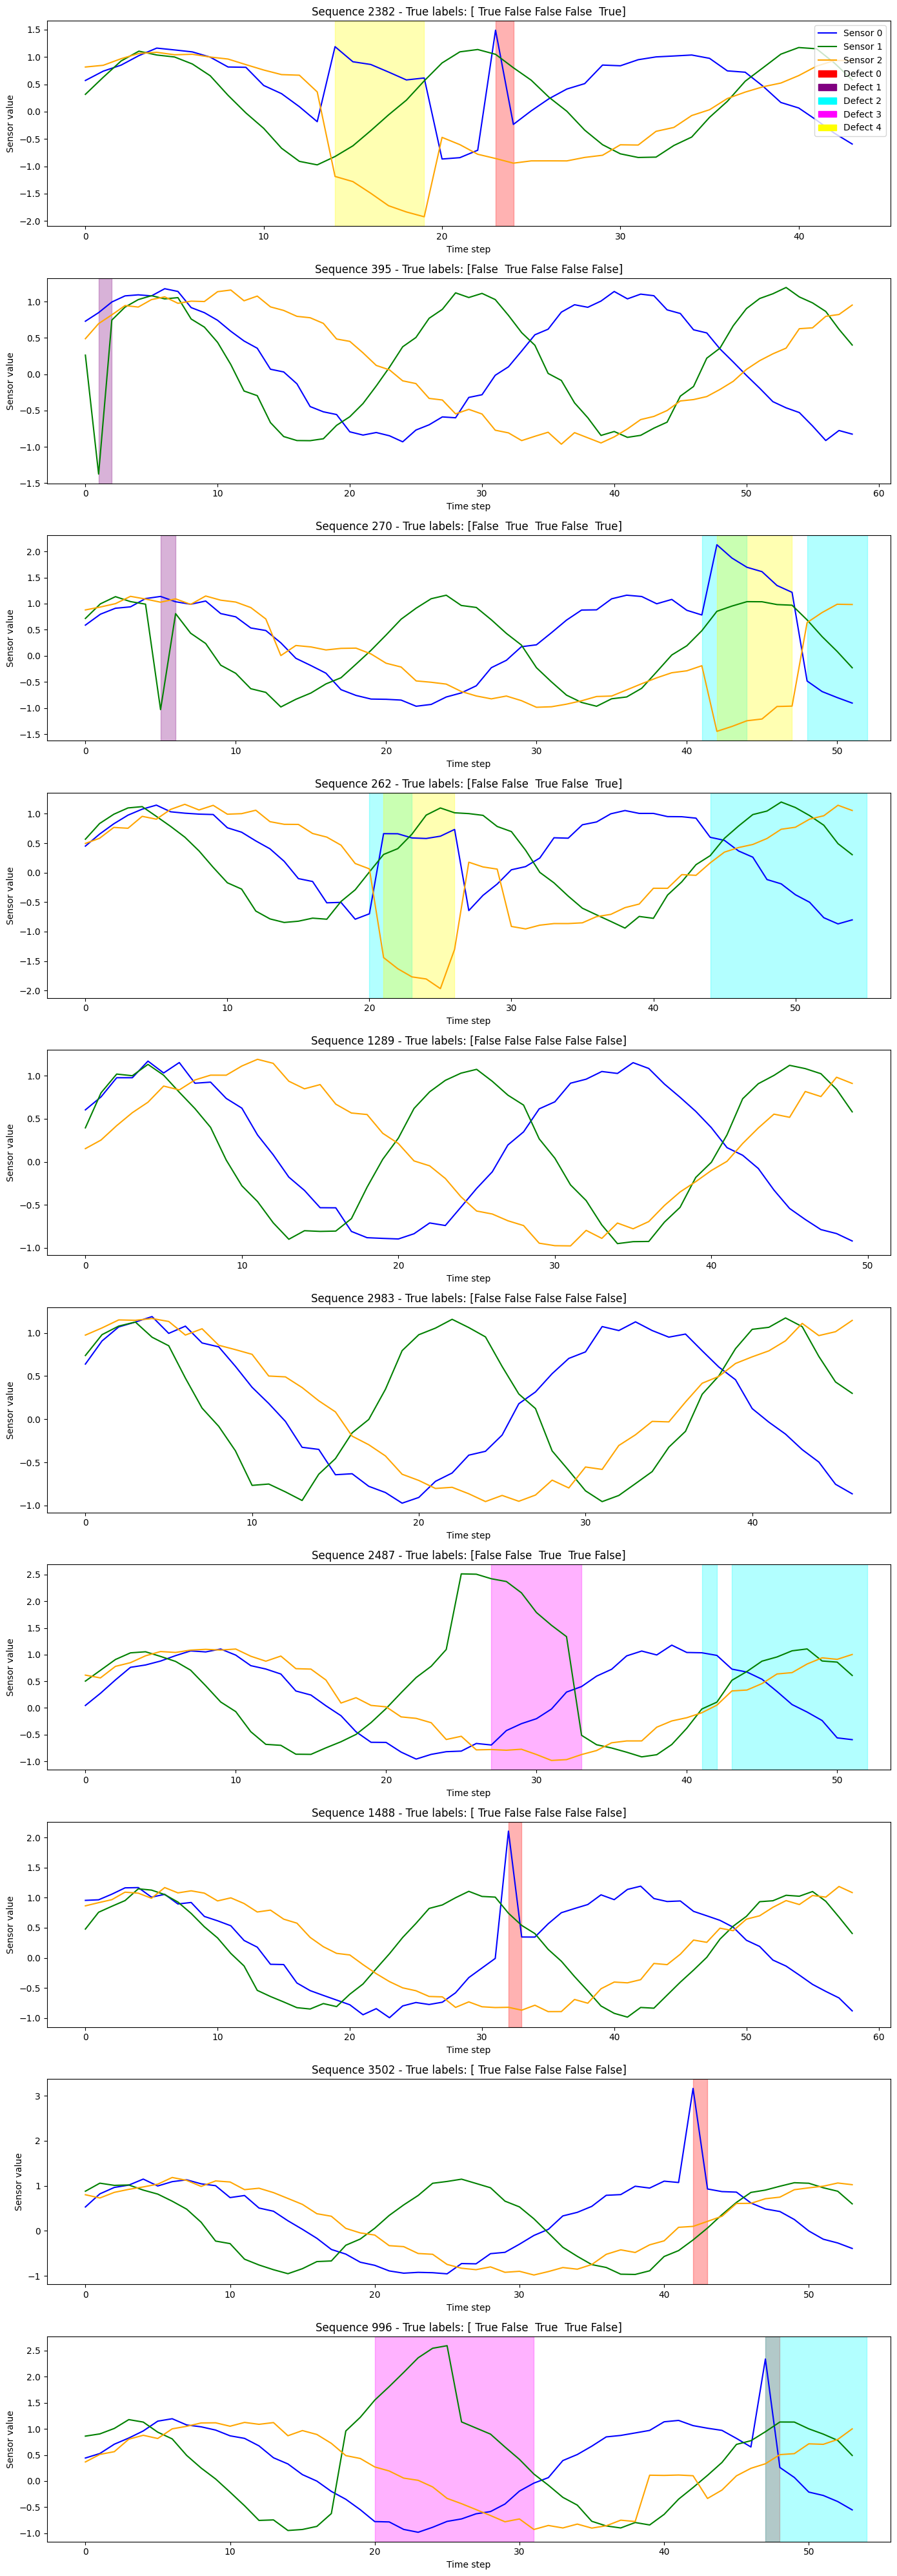

In [17]:
indices = np.random.choice(len(X_test), 10, replace=False)
visualize_batch_with_defects(model, X_test, y_test, indices=indices, threshold=0.7,max_plots=10)


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def createRow_with_intervals(n, classes):
    base = np.sin(np.linspace(np.random.rand(3), np.random.rand(3) + np.array([10,15,7]), n))
    intervals = []

    if classes[0] > 0:
        idx = np.random.randint(0, n)
        base[idx, 0] += 2
        intervals.append((0, idx, idx))

    if classes[1] > 0:
        idx = np.random.randint(0, n)
        base[idx, 1] -= 2
        intervals.append((1, idx, idx))

    if classes[2] > 0:
        start = np.random.randint(0, n-5)
        base[start:start+4, 2] = 0
        intervals.append((2, start, start+3))

    if classes[3] > 0:
        start = np.random.randint(0, n-10)
        base[start:start+8, 1] += 1.5
        intervals.append((3, start, start+7))

    if classes[4] > 0:
        start = np.random.randint(0, n-7)
        base[start:start+6, 0] += 1.5
        base[start:start+6, 2] -= 1.5
        intervals.append((4, start, start+5))

    # Add noise
    base += np.random.rand(*base.shape) * 0.2

    return base, intervals


def plot_random_sequences(num_sequences=10, min_len=40, max_len=60):

    colors = ["red", "purple", "cyan", "magenta", "yellow"]
    defect_names = [f"Defect {i}" for i in range(5)]
    
    fig, axs = plt.subplots(num_sequences, 1, figsize=(14, 4*num_sequences), sharex=False)
    if num_sequences == 1:
        axs = [axs]
    
    for i in range(num_sequences):
        n = np.random.randint(min_len, max_len+1)
        classes = np.random.rand(5) < 0.25  
        seq, intervals = createRow_with_intervals(n, classes)
        t = np.arange(n)
        
        ax = axs[i]
        ax.plot(t, seq[:,0], label="Sensor 0", color="blue")
        ax.plot(t, seq[:,1], label="Sensor 1", color="green")
        ax.plot(t, seq[:,2], label="Sensor 2", color="orange")
        
        for anomaly_idx, start, end in intervals:
            ax.add_patch(
                patches.Rectangle(
                    (start, ax.get_ylim()[0]),
                    end-start+1,
                    ax.get_ylim()[1]-ax.get_ylim()[0],
                    alpha=0.3,
                    color=colors[anomaly_idx % len(colors)]
                )
            )
            ax.text(start, ax.get_ylim()[1]*0.9, defect_names[anomaly_idx], color='white', fontsize=9)
        
        ax.set_title(f"Sequence {i} - Applied anomalies: {[a[0] for a in intervals]}")
        ax.set_xlabel("Time step")
        ax.set_ylabel("Sensor value")
        
        if i == 0:
            sensor_lines = [ax.lines[0], ax.lines[1], ax.lines[2]]
            defect_patches = [patches.Patch(color=colors[i], label=defect_names[i]) for i in range(5)]
            ax.legend(handles=sensor_lines + defect_patches, loc="upper right")
    
    plt.tight_layout()
    plt.show()


In [26]:
#plot_random_sequences(num_sequences=5, min_len=40, max_len=60)


In [20]:
def generate_dataset(num_sequences=20, min_len=40, max_len=60):
    X = []
    intervals_list = []

    for _ in range(num_sequences):
        n = np.random.randint(min_len, max_len + 1)
        classes = (np.random.rand(5) < 0.25).astype(int)

        seq, intervals = createRow_with_intervals(n, classes)

        X.append(seq)
        intervals_list.append(intervals)

    return X, intervals_list


In [21]:
import numpy as np

def intervals_to_frame_labels(intervals, T, n_classes=5):
    y = np.zeros((T, n_classes), dtype=np.int32)
    for cls, start, end in intervals:
        y[start:end+1, cls] = 1
    return y


In [31]:
def visualize_and_evaluate(
    model,
    X,                  
    intervals_list,  
    indices,
    threshold=0.5,
    max_plots=20
):
    device = next(model.parameters()).device
    model.eval()

    colors = ["red", "purple", "cyan", "magenta", "yellow"]
    defect_names = [f"Defect {i}" for i in range(5)]

    all_y_true = []
    all_y_pred = []

    n = min(len(indices), max_plots)
    fig, axs = plt.subplots(n, 1, figsize=(15, 4*n), sharex=False)
    if n == 1:
        axs = [axs]

    for plot_idx, idx in enumerate(indices[:n]):
        seq = X[idx]
        intervals = intervals_list[idx]
        T = len(seq)

        y_true = intervals_to_frame_labels(intervals, T)

        x_t = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
        lengths = torch.tensor([T]).to(device)

        with torch.no_grad():
            probs = model(x_t, lengths)[0].cpu().numpy()

        y_pred = (probs >= threshold).astype(int)

        all_y_true.append(y_true)
        all_y_pred.append(y_pred)

        t = np.arange(T)
        ax = axs[plot_idx]

        ax.plot(t, seq[:,0], label="Sensor 0", color="blue")
        ax.plot(t, seq[:,1], label="Sensor 1", color="green")
        ax.plot(t, seq[:,2], label="Sensor 2", color="orange")

        ymin, ymax = ax.get_ylim()

        for cls, start, end in intervals:
            ax.add_patch(
                patches.Rectangle(
                    (start, ymin),
                    end-start+1,
                    ymax-ymin,
                    alpha=0.35,
                    color=colors[cls]
                )
            )

        for cls in range(y_pred.shape[1]):
            active = y_pred[:, cls]
            start = None
            for i, v in enumerate(active):
                if v and start is None:
                    start = i
                elif not v and start is not None:
                    ax.add_patch(
                        patches.Rectangle(
                            (start, ymin),
                            i-start,
                            ymax-ymin,
                            fill=False,
                            hatch="///",
                            edgecolor=colors[cls],
                            linewidth=2
                        )
                    )
                    start = None
            if start is not None:
                ax.add_patch(
                    patches.Rectangle(
                        (start, ymin),
                        T-start,
                        ymax-ymin,
                        fill=False,
                        hatch="///",
                        edgecolor=colors[cls],
                        linewidth=2
                    )
                )

        ax.set_title(f"Sequence {idx}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Sensor value")

        if plot_idx == 0:
            legend_items = (
                [ax.lines[0], ax.lines[1], ax.lines[2]] +
                [patches.Patch(color=colors[i], label=f"{defect_names[i]} GT") for i in range(5)] +
                [patches.Patch(facecolor='none', edgecolor='black', hatch='///', label="Prediction")]
            )
            ax.legend(handles=legend_items, loc="upper right")

    plt.tight_layout()
    plt.show()

    y_true_all = np.concatenate(all_y_true, axis=0)
    y_pred_all = np.concatenate(all_y_pred, axis=0)

    metrics = {}
    for c in range(y_true_all.shape[1]):
        metrics[f"Defect {c}"] = {
            "accuracy": accuracy_score(y_true_all[:, c], y_pred_all[:, c]),
            "f1": f1_score(y_true_all[:, c], y_pred_all[:, c], zero_division=0)
        }

    metrics["macro_f1"] = f1_score(
        y_true_all, y_pred_all, average="macro", zero_division=0
    )

    return metrics


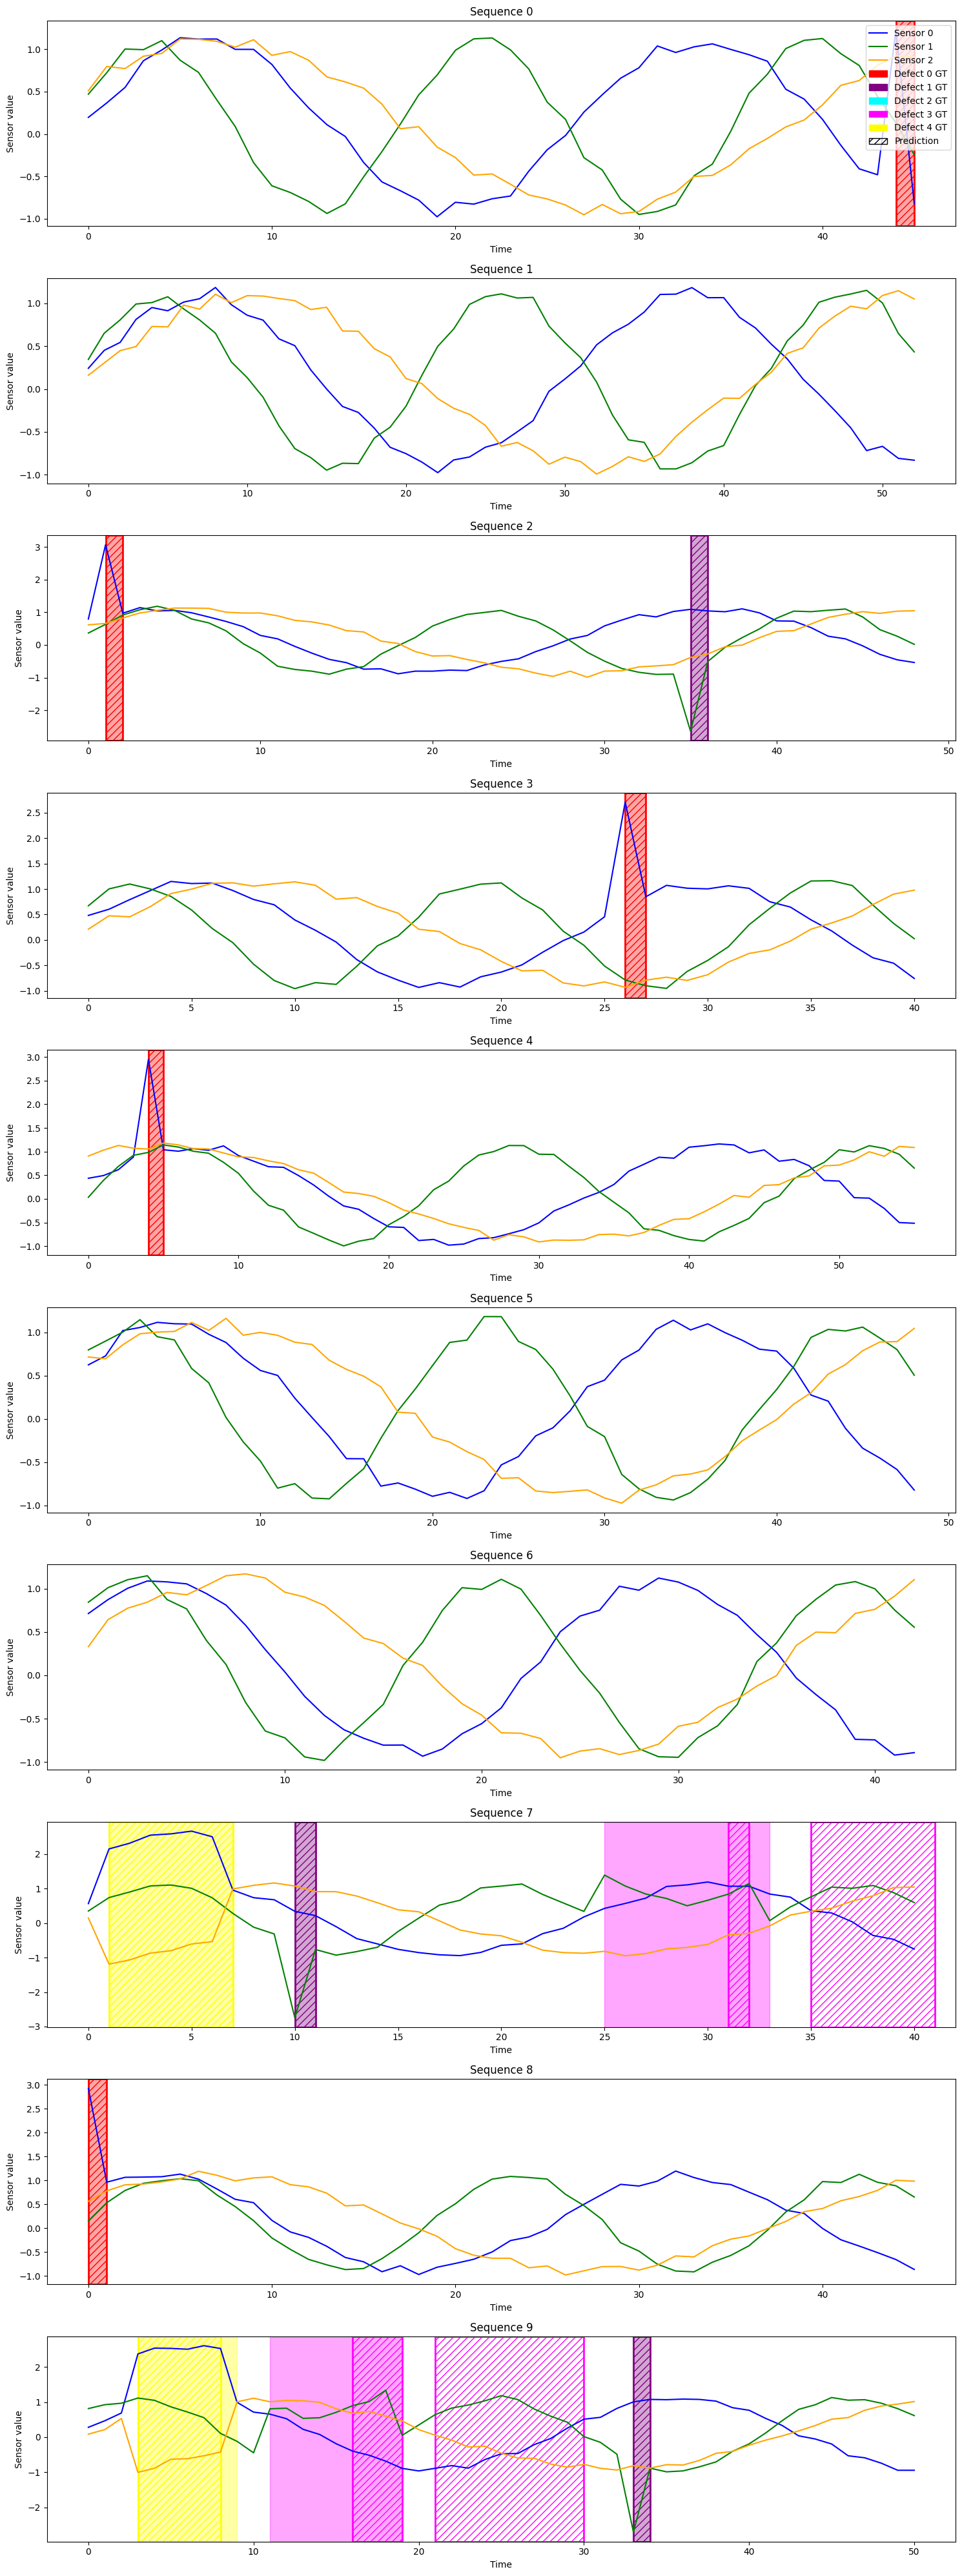

Defect 0 {'accuracy': 1.0, 'f1': 1.0}
Defect 1 {'accuracy': 1.0, 'f1': 1.0}
Defect 2 {'accuracy': 1.0, 'f1': 0.0}
Defect 3 {'accuracy': 0.9431578947368421, 'f1': 0.22857142857142856}
Defect 4 {'accuracy': 0.9978947368421053, 'f1': 0.9565217391304348}
macro_f1 0.6370186335403727


In [32]:
X, intervals_list = generate_dataset(num_sequences=30)

metrics = visualize_and_evaluate(
    model,
    X,
    intervals_list,
    indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
    threshold=0.7
)

for k, v in metrics.items():
    print(k, v)


In [33]:
def evaluate_all(model, X, intervals_list, threshold=0.5):
    device = next(model.parameters()).device
    model.eval()

    all_true, all_pred = [], []

    for seq, intervals in zip(X, intervals_list):
        T = len(seq)
        y_true = intervals_to_frame_labels(intervals, T)

        x_t = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
        lengths = torch.tensor([T]).to(device)

        with torch.no_grad():
            probs = model(x_t, lengths)[0].cpu().numpy()

        y_pred = (probs >= threshold).astype(int)

        all_true.append(y_true)
        all_pred.append(y_pred)

    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)

    metrics = {}
    for c in range(y_true_all.shape[1]):
        metrics[f"Defect {c}"] = {
            "accuracy": accuracy_score(y_true_all[:, c], y_pred_all[:, c]),
            "f1": f1_score(y_true_all[:, c], y_pred_all[:, c], zero_division=0)
        }
    metrics["macro_f1"] = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)

    return metrics


In [34]:

#visualize_and_evaluate(model, X, intervals_list, indices=[0,1,2,3,4], threshold=0.7)

metrics = evaluate_all(model, X, intervals_list, threshold=0.7)
metrics


{'Defect 0': {'accuracy': 1.0, 'f1': 1.0},
 'Defect 1': {'accuracy': 1.0, 'f1': 1.0},
 'Defect 2': {'accuracy': 0.9586720867208672, 'f1': 0.0},
 'Defect 3': {'accuracy': 0.9586720867208672, 'f1': 0.5271317829457365},
 'Defect 4': {'accuracy': 0.9939024390243902, 'f1': 0.926829268292683},
 'macro_f1': 0.6907922102476839}